In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tbplas as tb

cell = tb.make_graphene_diamond()

/home/ICN2/alapena/miniconda3/envs/tbplas/lib/python3.12/site-packages/tbplas/cython/__init__.py:54: UserWarning: C++ hdf5 extension not found. HDF5 IO not usable.
  warnings.warn("C++ hdf5 extension not found. HDF5 IO not usable.")


In [2]:
k_points = np.array([
    [0.0, 0.0, 0.0],    # Gamma
    [1./2, 0.0, 0.0],   # M
    [2./3, 1./3, 0.0],  # K
    [0.0, 0.0, 0.0],    # Gamma
])
k_label = ["G", "M", "K", "G"]
k_path, k_idx = tb.gen_kpath(k_points, [40, 40, 40])

In [3]:
use_diag_solver = True
if use_diag_solver:
    solver = tb.DiagSolver(cell)
    solver.config.k_points = k_path
    solver.config.prefix = "graphene"
    k_len, bands = solver.calc_bands()
else:
    k_len, bands = tb.calc_bands(cell, k_path, prefix="graphene")


Parallelization details:
  MPI disabled    
  OMP_NUM_THREADS  : n/a   
  MKL_NUM_THREADS  : n/a   

Output details:
  Directory  : ./
  Prefix     : graphene

Using Eigen backend for diagonalization.


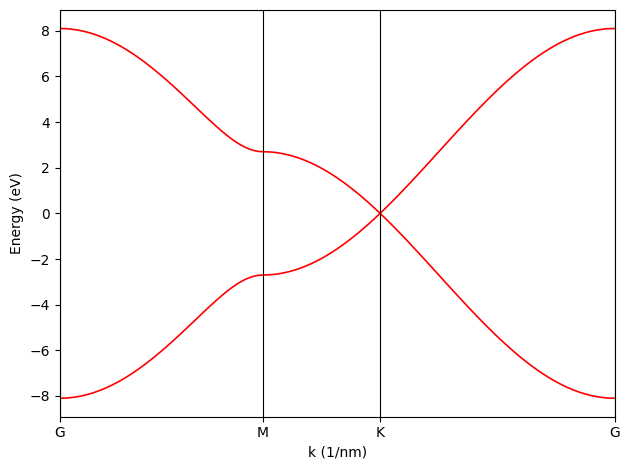

In [4]:
vis = tb.Visualizer()
vis.plot_bands(k_len, bands, k_idx, k_label)

# DOS

In [38]:
k_mesh = tb.gen_kmesh((40, 40, 40))  # 120*120*1 uniform meshgrid


Parallelization details:
  MPI disabled    
  OMP_NUM_THREADS  : n/a   
  MKL_NUM_THREADS  : n/a   

Output details:
  Directory  : ./
  Prefix     : graphene

Using Eigen backend for diagonalization.


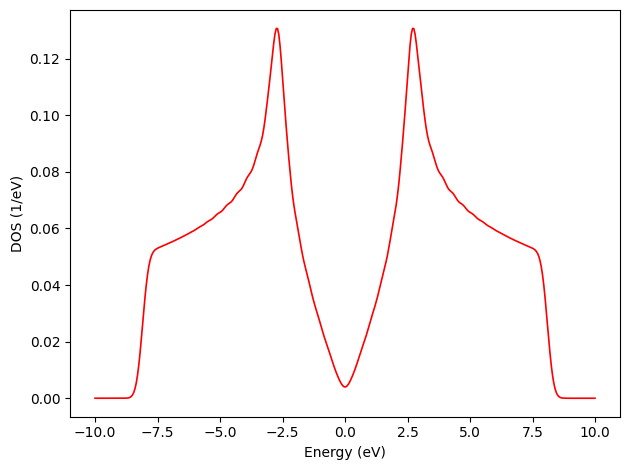

In [39]:
if use_diag_solver:
    solver = tb.DiagSolver(cell)
    solver.config.k_points = k_mesh
    solver.config.prefix = "graphene"
    solver.config.e_min = -10
    solver.config.e_max = 10
    solver.config.sigma = 0.2 # default: 0.05
    energies, dos = solver.calc_dos()
else:
    energies, dos = tb.calc_dos(cell, k_mesh, prefix="graphene", e_min=-10, e_max=10)

vis = tb.Visualizer()
vis.plot_dos(energies, dos)